In [12]:
csv_path = "./patches_dataset/patches_v1_seed42/metadata.csv"
data_path = "./patches_dataset/patches_v1_seed42"

In [13]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt

In [15]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PATCH_SIZE = 224

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)


root_dir = "./patches_dataset/patches_v2_seed42"
csv_path = os.path.join(root_dir, "metadata.csv")

df = pd.read_csv(csv_path)

required_cols = {"patch_id", "label", "type"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in metadata.csv: {missing}")

df["patch_id"] = df["patch_id"].astype(int)
df["label"] = df["label"].astype(int)
df["type"] = df["type"].astype(str)

device: mps


In [16]:
class PatchDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patch_id = int(row["patch_id"])
        label = int(row["label"])
        t = row["type"].strip().lower()

        subdir = "positive" if t == "positive" else "negative"
        img_path = os.path.join(self.root_dir, subdir, f"{patch_id}.png")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing patch file: {img_path}")

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        y = torch.tensor(label, dtype=torch.float32)
        return img, y

In [17]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
)

train_dataset = PatchDataset(train_df, root_dir=root_dir, transform=transform)
test_dataset  = PatchDataset(test_df,  root_dir=root_dir, transform=transform)

print("train/test:", len(train_dataset), len(test_dataset))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)


train/test: 7056 1764


In [18]:
class SimpleCNN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # 3 bc RGB 
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # archi 16/32/64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.head = nn.Linear(64, 1) # couche classif finale FC, classif binaire donc 1 score suffit

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x) # pour non linéarité sans vanishing gradient
        x = self.pool(x)
    
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
    
        x = self.conv3(x)
        x = F.relu(x)
        x = self.pool(x)
    
        x = x.mean(dim=(2, 3)) #global avg pooling : moyenner chaque feature map en un chiffre
    
        x = self.head(x) # [batch_size,1] devient...
        logits = x.squeeze(1) # [batch_size] (vect)
        return logits


model = SimpleCNN3().to(device)

In [19]:
pos = (train_df["label"] == 1).sum()
neg = (train_df["label"] == 0).sum()
pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) #std pour classif binaire
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [20]:
def train_one_epoch():
    model.train() # start training
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader: # load batches
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad() # gradients remis à 0
        logits = model(x) # fwd pass
        loss = criterion(logits, y) # calcule erreur 
        loss.backward() # calcule gradients
        optimizer.step() # maj poids avce gradients

        total_loss += loss.item() * x.size(0) # pour moyenner sur epoch apres 

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float() # ICI SEUIL DEFINI ---------------------------------------------------------------------------------
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad() # pas en eval...
def evaluate_scores(loader):
    model.eval()
    all_scores = []
    all_labels = []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits).detach().cpu().numpy() #sigmoide pour PASSAGE AUX PROBAS
        all_scores.append(probs)
        all_labels.append(y.numpy())

    scores = np.concatenate(all_scores, axis=0).astype(np.float64)
    labels = np.concatenate(all_labels, axis=0).astype(np.int32)
    return scores, labels

In [21]:
epochs = 10
for epoch in range(epochs):
    loss, acc = train_one_epoch()
    print(f"Epoch {epoch} | Loss {loss:.4f} | Acc {acc:.4f}")


scores, labels = evaluate_scores(test_loader)

Epoch 0 | Loss 0.5236 | Acc 0.5955
Epoch 1 | Loss 0.5075 | Acc 0.6465
Epoch 2 | Loss 0.4969 | Acc 0.6648
Epoch 3 | Loss 0.4905 | Acc 0.6706
Epoch 4 | Loss 0.4906 | Acc 0.6715
Epoch 5 | Loss 0.4813 | Acc 0.6756
Epoch 6 | Loss 0.4739 | Acc 0.6834
Epoch 7 | Loss 0.4660 | Acc 0.6918
Epoch 8 | Loss 0.4604 | Acc 0.6925
Epoch 9 | Loss 0.4570 | Acc 0.6926


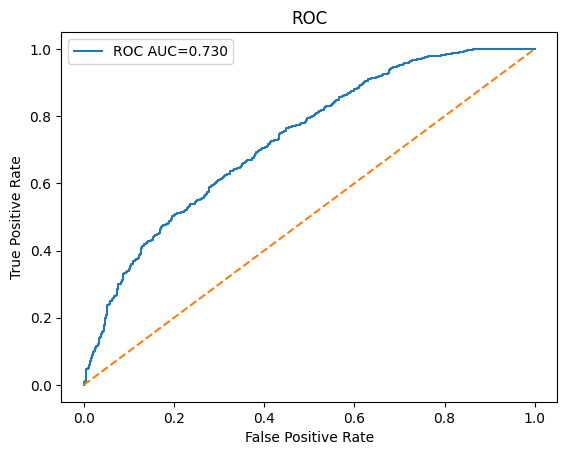

In [22]:
fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

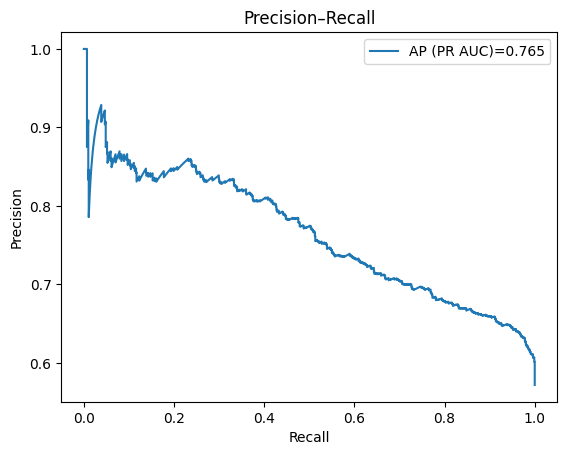

In [23]:
prec, rec, _ = precision_recall_curve(labels, scores)
ap = average_precision_score(labels, scores)

plt.figure()
plt.plot(rec, prec, label=f"AP (PR AUC)={ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall")
plt.legend()
plt.show()


In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
preds = (scores >= 0.5).astype(int)
print(confusion_matrix(labels, preds))

# { TN FP 
# FN TP }

[[382 373]
 [214 795]]


In [26]:
print("                            Métriques")
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

                            Métriques
              precision    recall  f1-score   support

    Negative       0.64      0.51      0.57       755
    Positive       0.68      0.79      0.73      1009

    accuracy                           0.67      1764
   macro avg       0.66      0.65      0.65      1764
weighted avg       0.66      0.67      0.66      1764



In [27]:
preds = (scores >= 0.7).astype(int) # moins bon, seuil plus serré...
print(confusion_matrix(labels, preds))

# { TN FP 
# FN TP }

[[662  93]
 [621 388]]


In [28]:
print("                            Métriques")
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

                            Métriques
              precision    recall  f1-score   support

    Negative       0.52      0.88      0.65       755
    Positive       0.81      0.38      0.52      1009

    accuracy                           0.60      1764
   macro avg       0.66      0.63      0.59      1764
weighted avg       0.68      0.60      0.58      1764



In [29]:
# oversampling des negatifs ? pour equlibrer dataset
# taille kernel ?
# reduire learning rate 
# automatiser test avec differents seeds
# essayer de ne pas manquer d'arbres, trop de faux negatifs cf precision negative : 0.83 avec seuil à 0.5, pire avec 0.7

